# Intro to MLOps — model decay & monitoring (notebook 4)Models don't stay good forever. The world drifts — customer behaviour shifts,prices change, new segments show up — and a model trained on last quarter'sdata quietly gets worse on this quarter's traffic. This notebook takes the**churn model from notebook 2** and:1. simulates 12 weeks of production traffic that **drifts** starting partway   through,2. **monitors** accuracy in (near) real time by logging one metric per week to   MLflow — the same call a scheduled job or streaming consumer would make,3. **detects** the decay against a simple threshold, and4. applies the simplest real **mitigation**: retrain on the recent, drifted   data.- Tutorial: <https://jienweng.github.io/notes/intro-to-mlops-tutorial/>- Slides:   <https://jienweng.github.io/slides/2026/intro-to-mlops/>**How to use this notebook**1. `pip install -r requirements.txt`2. Run all cells top to bottom.3. Watch the printed weekly accuracy fall after week 6, then recover after   the retraining cell.4. Optionally open the UI to see the same curve MLflow recorded:   `mlflow ui --backend-store-uri sqlite:///mlflow.db` → experiment   `churn-monitoring`.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('churn-monitoring')

rng = np.random.default_rng(7)

/Users/jienweng/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/07/01 17:26:21 INFO mlflow.tracking.fluent: Experiment with name 'churn-monitoring' does not exist. Creating a new experiment.


## Baseline — the model as shippedSame churn model as notebook 2, trained once and then frozen. This is "themodel in production" for the rest of the notebook — nothing below ever calls`.fit()` on it again.

In [2]:
df = pd.read_csv('churn.csv')
y_all = (df['churn'] == 'Yes').astype(int)
X_all = pd.get_dummies(df.drop(columns='churn'), drop_first=True)
X_all = X_all.astype({c: int for c in X_all.columns if X_all[c].dtype == bool})

# X_train trains the frozen model; X_pool is held out and stands in for
# "future production traffic" that we sample from and drift below.
X_train, X_pool, y_train, y_pool = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, stratify=y_all)

model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
model.fit(X_train, y_train)

baseline_acc = accuracy_score(y_pool, model.predict(X_pool))
print(f'Baseline accuracy (frozen model, undrifted data): {baseline_acc:.3f}')

Baseline accuracy (frozen model, undrifted data): 0.757


## Simulate 12 weeks of production traffic, drifting from week 6Each week we resample a batch of customers from the held-out pool. From week 6onward the batch is nudged away from what the model was trained on: customersskew newer (lower tenure), file more support tickets, and `total_charges` isrecomputed to stay internally consistent with the new tenure — a plausiblegrowth-driven shift, not a manufactured contradiction.

In [3]:
N_WEEKS = 12
DRIFT_STARTS_AT = 6   # week index where the customer base starts changing
BATCH_SIZE = 150      # customers scored per week (resampled from the pool)

def drift(X_batch, week):
    """Simulate one week's incoming batch, increasingly out-of-distribution after week 6."""
    X_batch = X_batch.copy()
    if week >= DRIFT_STARTS_AT:
        severity = week - DRIFT_STARTS_AT + 1
        X_batch['tenure_months'] = (X_batch['tenure_months'] * (1 - 0.12 * severity)).clip(lower=0)
        X_batch['num_support_tickets'] = (X_batch['num_support_tickets'] + 0.8 * severity).clip(upper=15)
        X_batch['total_charges'] = X_batch['tenure_months'] * X_batch['monthly_charges']
    return X_batch

## Monitor: log one metric per weekFor each week, score the frozen model on that week's (possibly drifted) batchand log accuracy to MLflow with `step=week`. That single call is the wholemonitoring mechanism — in production, a scheduled job would make this exactcall once a batch of labelled outcomes becomes available.

In [4]:
weekly_acc = []
drifted_batches = []  # keep each week's data so the mitigation cell can reuse it
pool_idx = X_pool.index.to_numpy()

with mlflow.start_run(run_name='churn-model-monitoring'):
    mlflow.log_metric('baseline_accuracy', baseline_acc)

    for week in range(N_WEEKS):
        sample_idx = rng.choice(pool_idx, size=BATCH_SIZE, replace=True)
        X_week = drift(X_pool.loc[sample_idx], week)
        y_week = y_pool.loc[sample_idx]
        drifted_batches.append((X_week, y_week))

        acc = accuracy_score(y_week, model.predict(X_week))
        weekly_acc.append(acc)
        mlflow.log_metric('accuracy', acc, step=week)
        print(f'week {week:2d}: accuracy={acc:.3f}')

week  0: accuracy=0.747
week  1: accuracy=0.767
week  2: accuracy=0.733
week  3: accuracy=0.760
week  4: accuracy=0.840
week  5: accuracy=0.727
week  6: accuracy=0.767
week  7: accuracy=0.727
week  8: accuracy=0.687
week  9: accuracy=0.673
week 10: accuracy=0.560
week 11: accuracy=0.493


## Spot the decayA simple, common rule: flag decay once accuracy drops more than 0.05 belowbaseline. A real system would tune that margin and require it to hold for acouple of consecutive windows before paging anyone; one crossing is enoughhere to keep things simple.

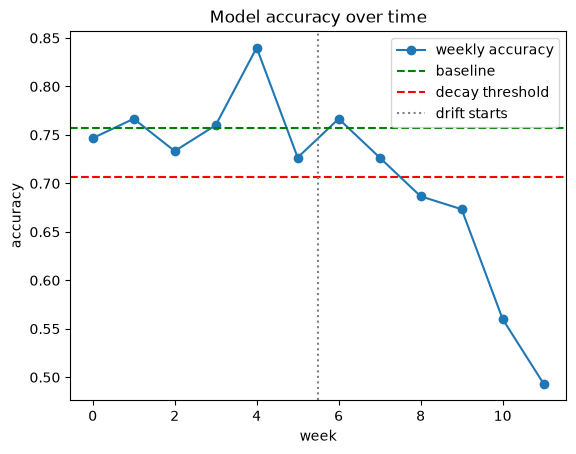

Decay detected at week 8: accuracy 0.687 is more than 0.05 below baseline (0.757).


In [5]:
THRESHOLD = baseline_acc - 0.05

plt.plot(weekly_acc, marker='o', label='weekly accuracy')
plt.axhline(baseline_acc, color='green', linestyle='--', label='baseline')
plt.axhline(THRESHOLD, color='red', linestyle='--', label='decay threshold')
plt.axvline(DRIFT_STARTS_AT - 0.5, color='gray', linestyle=':', label='drift starts')
plt.xlabel('week'); plt.ylabel('accuracy'); plt.legend()
plt.title('Model accuracy over time')
plt.show()

decay_week = next((w for w, a in enumerate(weekly_acc) if a < THRESHOLD), None)
if decay_week is not None:
    print(f'Decay detected at week {decay_week}: accuracy {weekly_acc[decay_week]:.3f} '
          f'is more than 0.05 below baseline ({baseline_acc:.3f}).')
else:
    print('No decay crossed the threshold.')

## Mitigate: retrain on recent dataThe simplest real mitigation there is: once decay is flagged, stop trustingthe stale training set and refit on the most recent (drifted) batches instead— they now describe the customers you are actually serving. We check the gainon the two most recent weeks, which neither model has trained on.This assumes labels for the recent weeks are already known, which isrealistic for churn (the outcome resolves within weeks) but not forpredictions that must be judged instantly.

In [6]:
if decay_week is not None and decay_week <= N_WEEKS - 3:
    retrain_X = pd.concat([X for X, _ in drifted_batches[decay_week:-2]])
    retrain_y = pd.concat([y for _, y in drifted_batches[decay_week:-2]])
    eval_X = pd.concat([X for X, _ in drifted_batches[-2:]])
    eval_y = pd.concat([y for _, y in drifted_batches[-2:]])

    retrained = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
    retrained.fit(retrain_X, retrain_y)

    before = accuracy_score(eval_y, model.predict(eval_X))
    after = accuracy_score(eval_y, retrained.predict(eval_X))

    with mlflow.start_run(run_name='churn-model-retrain-mitigation'):
        mlflow.log_param('retrained_on_weeks', f'{decay_week}-{N_WEEKS - 3}')
        mlflow.log_metric('accuracy_before_retrain', before)
        mlflow.log_metric('accuracy_after_retrain', after)
        mlflow.sklearn.log_model(retrained, name='model')

    print(f'On the final two weeks — stale model: {before:.3f}, retrained model: {after:.3f}')
else:
    print('Nothing to mitigate — no decay detected early enough to leave weeks to evaluate on.')

2026/07/01 17:26:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


On the final two weeks — stale model: 0.527, retrained model: 0.810


## Recap- **Monitor** — log one metric per time step (`step=week`); the curve in the  MLflow UI *is* the dashboard. In production this is the same job Prometheus  + Grafana do at larger scale (the monitoring box from the workflow diagram  earlier in the tutorial).- **Detect** — a threshold on that metric is enough to flag decay; no new tool  required.- **Mitigate** — retraining on recent data is the cheapest fix, and it doesn't  require redesigning the model, only refitting it on data that looks like  what you're serving now.View it all: `mlflow ui --backend-store-uri sqlite:///mlflow.db` → the`churn-monitoring` experiment.